# Spectral Methods and Fourier Analysis

This notebook is the second stop in the `01_foundations_extensions` research track.

The core path used a finite-difference baseline to anchor the PINN story. Here we go one step further in the numerical-analysis direction and trade *local* stencils for *global* spectral approximations. The reason is twofold:

1. spectral methods give the cleanest possible numerical reference when the solution is smooth (exponential convergence up to machine precision),
2. their underlying Fourier/Chebyshev analysis is exactly the lens that makes *spectral bias* of neural networks legible later in `03_neural_network_function_approximation.ipynb` and in the FNO notebook.

We reuse the canonical scalar field from the autodiff notebook, $u(x) = \sin(\pi x)\,e^{-x^2}$, so the same function appears in three forms: as a continuous PDE solution, as a finite-difference vector, and now as a Chebyshev-mode expansion.

## Notebook Contract

- **Status:** research-executable
- **Lane:** `10_Research_Tracks/01_foundations_extensions`
- **Research question:** how does a global spectral method (Chebyshev collocation) compare to a local finite-difference stencil for a smooth Poisson problem, and what spectrum does the underlying solution live on?
- **Canonical problem:** 1D Poisson $-u''(x) = f(x)$ on $[-1, 1]$ with homogeneous Dirichlet $u(\pm 1) = 0$ and smooth manufactured solution $u^*(x) = \sin(\pi x)\,e^{-x^2}$.
- **Prerequisites:** finite-difference baseline from `01_Core_Path/01_pde_primer_and_numerical_methods.ipynb`, autodiff operators from `01_automatic_differentiation_for_physics.ipynb`.
- **Deliverable:** convergence comparison of FD ($O(h^2)$) vs Chebyshev collocation (exponential), plus the Chebyshev amplitude spectrum of $u^*$ and a controlled experiment showing how that spectrum widens when the solution becomes less regular.
- **Estimated runtime:** under 1 minute on CPU.
- **References:**
  - Trefethen. *Spectral Methods in MATLAB*. SIAM, 2000.
  - Boyd. *Chebyshev and Fourier Spectral Methods*. Dover, 2001.
  - Canuto, Hussaini, Quarteroni, Zang. *Spectral Methods*. Springer, 2006.
- **Next notebooks:** [03_neural_network_function_approximation.ipynb](03_neural_network_function_approximation.ipynb).

## Why This Notebook Exists

PINN training is sensitive to the *resolution content* of the target. A smooth solution mostly lives in a few low Chebyshev modes; a sharp solution spreads across many. The numerical reference solver tells us, ahead of time, how many modes a problem really needs, which directly informs collocation density, network width, and the choice between a local and global method.

More importantly, the Chebyshev amplitude spectrum is the *same object* that determines whether a PINN learns fast or stalls: low-mode targets are easy for gradient descent, broad-spectrum targets are hard. We make that explicit with a side-by-side smoothness-controlled study at the end.

## Setup

We keep a single domain, $[-1, 1]$, throughout. SymPy supplies the exact forcing $f = -u''$; NumPy/SciPy do the linear algebra; Matplotlib draws the convergence and spectrum plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import torch

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

x_sym = sp.symbols("x", real=True)
u_sym = sp.sin(sp.pi * x_sym) * sp.exp(-(x_sym ** 2))
f_sym = -sp.diff(u_sym, x_sym, 2)

u_exact_np = sp.lambdify(x_sym, u_sym, "numpy")
f_exact_np = sp.lambdify(x_sym, sp.simplify(f_sym), "numpy")

print(f"Repo root: {repo_root}")
print(f"NumPy:    {np.__version__}")
print(f"SciPy:    {__import__('scipy').__version__}")
print(f"PyTorch:  {torch.__version__}")
print(f"Device:   {device}")
print(f"u  = {u_sym}")
print(f"f  = -u'' = {sp.simplify(f_sym)}")

Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy:    2.4.3
SciPy:    1.17.1
PyTorch:  2.10.0+cu128
Device:   cpu
u  = exp(-x**2)*sin(pi*x)
f  = -u'' = (4*pi*x*cos(pi*x) + (2 - 4*x**2)*sin(pi*x) + pi**2*sin(pi*x))*exp(-x**2)


## Canonical PDE, Recast onto $[-1, 1]$

We solve

$$ -u''(x) = f(x), \qquad x \in (-1, 1), \qquad u(-1) = u(1) = 0, $$

with the manufactured solution $u^*(x) = \sin(\pi x)\,e^{-x^2}$, which is smooth and exactly satisfies both Dirichlet conditions. The forcing is $f = -u^*$ in closed form via SymPy.

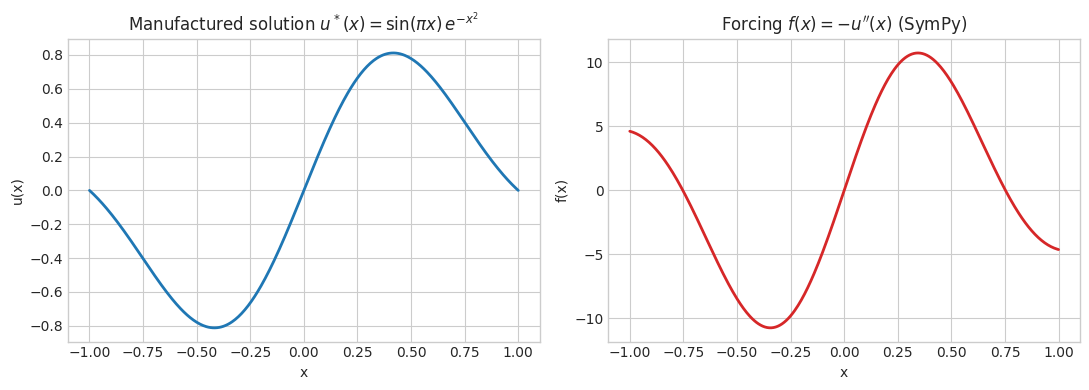

In [2]:
grid = np.linspace(-1.0, 1.0, 401)
u_plot = u_exact_np(grid)
f_plot = f_exact_np(grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(grid, u_plot, color="tab:blue", linewidth=2)
axes[0].set_title(r"Manufactured solution $u^*(x) = \sin(\pi x)\,e^{-x^2}$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")

axes[1].plot(grid, f_plot, color="tab:red", linewidth=2)
axes[1].set_title(r"Forcing $f(x) = -u''(x)$ (SymPy)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
plt.tight_layout()
plt.show()

## Method 1: Finite Differences, Revisited

On a uniform grid of $N+1$ interior-capped nodes the standard second-order stencil gives a tridiagonal system

$$ \frac{-u_{i-1} + 2 u_i - u_{i+1}}{h^2} = f(x_i), \qquad i = 1, \dots, N-1, $$

with $u_0 = u_N = 0$. Truncation error is $O(h^2)$. We keep this solver to anchor the convergence plot later.

FD N=41 | h=0.0500 | max error=2.580e-03


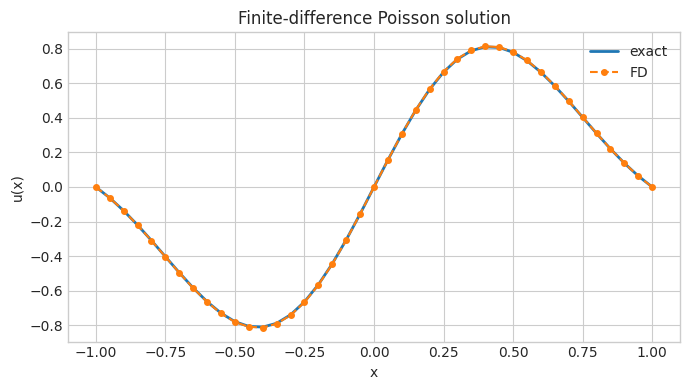

In [3]:
def solve_poisson_fd(num_grid_points: int):
    if num_grid_points < 3:
        raise ValueError("need at least 3 grid points")
    x = np.linspace(-1.0, 1.0, num_grid_points)
    h = x[1] - x[0]
    n_inner = num_grid_points - 2
    x_inner = x[1:-1]

    main = 2.0 * np.ones(n_inner)
    off = -1.0 * np.ones(n_inner - 1)
    A = (np.diag(main) + np.diag(off, k=1) + np.diag(off, k=-1)) / (h ** 2)
    b = f_exact_np(x_inner)
    u_inner = np.linalg.solve(A, b)
    u = np.zeros_like(x)
    u[1:-1] = u_inner
    return x, u, h

x_fd, u_fd, h_fd = solve_poisson_fd(41)
err_fd = np.max(np.abs(u_fd - u_exact_np(x_fd)))
print(f"FD N=41 | h={h_fd:.4f} | max error={err_fd:.3e}")

plt.figure(figsize=(7, 4))
plt.plot(x_fd, u_exact_np(x_fd), label="exact", linewidth=2)
plt.plot(x_fd, u_fd, "o--", markersize=4, label="FD")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Finite-difference Poisson solution")
plt.legend()
plt.tight_layout()
plt.show()

## Method 2: Chebyshev Collocation

Chebyshev methods place nodes at $x_k = \cos(k\pi/N)$, dense near the boundaries where shocks and boundary layers tend to live, and build a global differentiation matrix $D$ whose entries are explicit. The second derivative operator is $D^2 = D D$. Dirichlet conditions replace the boundary rows, and the interior values are solved from the resulting dense linear system.

For a smooth solution the error decays faster than any algebraic power of $1/N$; for an analytic target like ours it decays *exponentially* until machine precision.

In [4]:
def cheb_nodes(n: int) -> np.ndarray:
    if n < 1:
        raise ValueError("need at least one interior node")
    k = np.arange(n + 1)
    return np.cos(np.pi * k / n)


def cheb_differentiation_matrix(n: int) -> np.ndarray:
    x = cheb_nodes(n)
    c = np.ones(n + 1)
    c[0] = 2.0
    c[-1] = 2.0
    c = c * ((-1.0) ** np.arange(n + 1))
    D = np.zeros((n + 1, n + 1))
    for i in range(n + 1):
        for j in range(n + 1):
            if i != j:
                D[i, j] = (c[i] / c[j]) / (x[i] - x[j])
    for i in range(n + 1):
        D[i, i] = -np.sum(D[i, :])
    return x, D

In [5]:
n_test = 8
x_test, D_test = cheb_differentiation_matrix(n_test)
ones = D_test @ np.ones(n_test + 1)
poly_check = D_test @ x_test - np.ones(n_test + 1)

print("D @ 1 (should be zero):", np.max(np.abs(ones)))
print("D @ x - 1 (should be zero):", np.max(np.abs(poly_check)))

u_test = u_exact_np(x_test)
ux_test = sp.lambdify(x_sym, sp.diff(u_sym, x_sym), "numpy")(x_test)
print("max |D u - u'_exact|:", np.max(np.abs(D_test @ u_test - ux_test)))

D @ 1 (should be zero): 3.552713678800501e-15
D @ x - 1 (should be zero): 3.552713678800501e-15
max |D u - u'_exact|: 0.10493574919699666


Chebyshev n=16 | max error = 2.182e-08


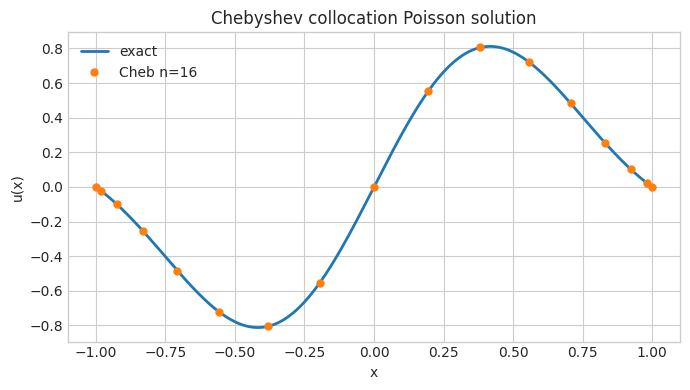

In [6]:
def solve_poisson_cheb(n: int):
    x, D = cheb_differentiation_matrix(n)
    D2 = D @ D
    interior = np.arange(1, n)
    A = D2[np.ix_(interior, interior)]
    rhs = -f_exact_np(x[interior])
    rhs = rhs - D2[np.ix_(interior, [0, n])] @ np.array([0.0, 0.0])
    u_inner = np.linalg.solve(A, rhs)
    u = np.zeros(n + 1)
    u[interior] = u_inner
    return x, u

x_c, u_c = solve_poisson_cheb(16)
err_c = np.max(np.abs(u_c - u_exact_np(x_c)))
print(f"Chebyshev n=16 | max error = {err_c:.3e}")

plt.figure(figsize=(7, 4))
plt.plot(grid, u_exact_np(grid), label="exact", linewidth=2)
plt.plot(x_c, u_c, "o", markersize=5, label="Cheb n=16")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Chebyshev collocation Poisson solution")
plt.legend()
plt.tight_layout()
plt.show()

## Convergence Race: Local vs Global

We sweep the number of nodes for both methods and record the maximum error. Finite differences fall along an $O(h^2)$ line; Chebyshev collocation dies exponentially and bottoms out at machine precision already for $n \approx 20$.

FD N      max err       
9         6.113e-02     
17        1.636e-02     
33        4.044e-03     
65        1.008e-03     
129       2.519e-04     
257       6.299e-05     
513       1.575e-05     
1025      3.937e-06     
---
Cheb n    max err       
4         3.577e-01     
8         2.435e-03     
12        9.191e-06     
16        2.182e-08     
20        3.173e-11     
24        2.998e-14     
32        3.109e-15     
48        1.554e-14     
64        1.321e-14     


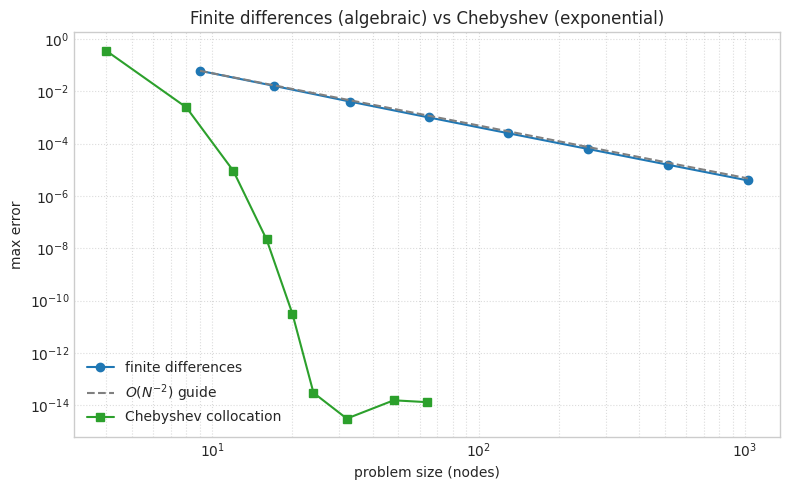

In [7]:
fd_sizes = [9, 17, 33, 65, 129, 257, 513, 1025]
cheb_sizes = [4, 8, 12, 16, 20, 24, 32, 48, 64]

fd_errs = []
fd_hs = []
for n in fd_sizes:
    x_n, u_n, h_n = solve_poisson_fd(n)
    fd_errs.append(np.max(np.abs(u_n - u_exact_np(x_n))))
    fd_hs.append(h_n)

cheb_errs = []
cheb_n = []
for n in cheb_sizes:
    x_n, u_n = solve_poisson_cheb(n)
    cheb_errs.append(np.max(np.abs(u_n - u_exact_np(x_n))))
    cheb_n.append(n)

print(f"{'FD N':<10}{'max err':<14}")
for n, e in zip(fd_sizes, fd_errs):
    print(f"{n:<10}{e:<14.3e}")
print("---")
print(f"{'Cheb n':<10}{'max err':<14}")
for n, e in zip(cheb_sizes, cheb_errs):
    print(f"{n:<10}{e:<14.3e}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.loglog(fd_sizes, fd_errs, "o-", label="finite differences")
ax.loglog(fd_sizes, fd_errs[0] * (np.array(fd_sizes[0]) / np.array(fd_sizes)) ** 2, "--", color="gray", label=r"$O(N^{-2})$ guide")
ax.semilogy(cheb_sizes, cheb_errs, "s-", color="tab:green", label="Chebyshev collocation")
ax.set_xlabel("problem size (nodes)")
ax.set_ylabel("max error")
ax.set_title("Finite differences (algebraic) vs Chebyshev (exponential)")
ax.legend(loc="lower left")
ax.grid(True, which="both", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

## Chebyshev Spectrum of the Solution

The hidden quantity behind that exponential convergence is the decay of the Chebyshev expansion coefficients of $u^*$. We fit a Chebyshev series at high resolution and plot $|a_k|$ on a log scale. For an analytic target the coefficients drop geometrically until they hit the round-off floor.

This spectrum is what an operator-learning model like FNO has to reproduce mode by mode, and what an MLP tends to fill in slowly because of spectral bias.

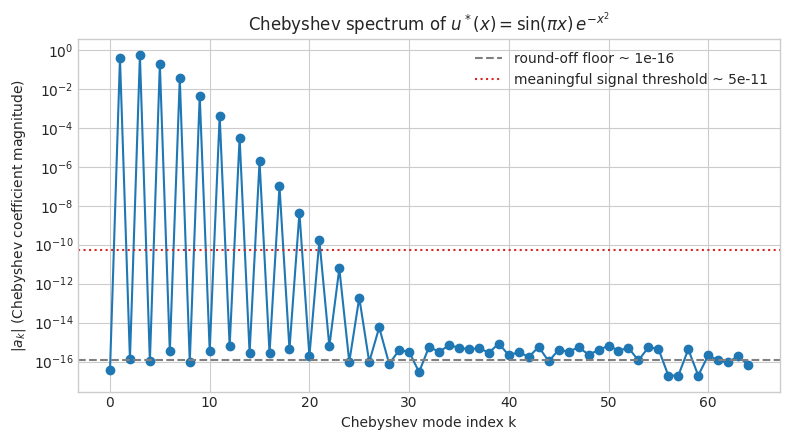

Chebyshev modes above the meaningful threshold: 11 out of 65
(this matches the convergence onset n ~ 22 from the previous plot)


In [8]:
n_spec = 64
x_spec = cheb_nodes(n_spec)
u_vals = u_exact_np(x_spec)
cheb_coeffs = np.polynomial.chebyshev.chebfit(x_spec, u_vals, n_spec)
cheb_coeffs = np.abs(cheb_coeffs)

floor = np.finfo(float).eps * np.max(cheb_coeffs)
threshold = 1e-10 * np.max(cheb_coeffs)

plt.figure(figsize=(8, 4.5))
plt.semilogy(np.arange(len(cheb_coeffs)), cheb_coeffs, "o-")
plt.axhline(floor, color="gray", linestyle="--", label=f"round-off floor ~ {floor:.0e}")
plt.axhline(threshold, color="tab:red", linestyle=":", label=f"meaningful signal threshold ~ {threshold:.0e}")
plt.xlabel("Chebyshev mode index k")
plt.ylabel(r"$|a_k|$ (Chebyshev coefficient magnitude)")
plt.title(r"Chebyshev spectrum of $u^*(x) = \sin(\pi x)\,e^{-x^2}$")
plt.legend()
plt.tight_layout()
plt.show()

n_meaningful = int(np.sum(cheb_coeffs > threshold))
print(f"Chebyshev modes above the meaningful threshold: {n_meaningful} out of {len(cheb_coeffs)}")
print(f"(this matches the convergence onset n ~ {2 * n_meaningful} from the previous plot)")

## Smoothness Probe: When Spectral Convergence Softens

The promise of exponential convergence only holds for *smooth* targets. We test the boundary of that promise by shrinking the width of a Gaussian bump inside the same Dirichlet-satisfying ansatz

$$ u_\sigma(x) = \sin(\pi x)\, \exp\!\left(-\frac{x^2}{\sigma^2}\right). $$

As $\sigma$ gets smaller the solution localizes, and the underlying Chebyshev spectrum broadens. We track how many modes must be retained above the round-off floor for $\sigma \in \{2.0, 0.6, 0.25\}$. This is a faithful prototype for why localized features make both spectral solvers *and* PINN training harder.

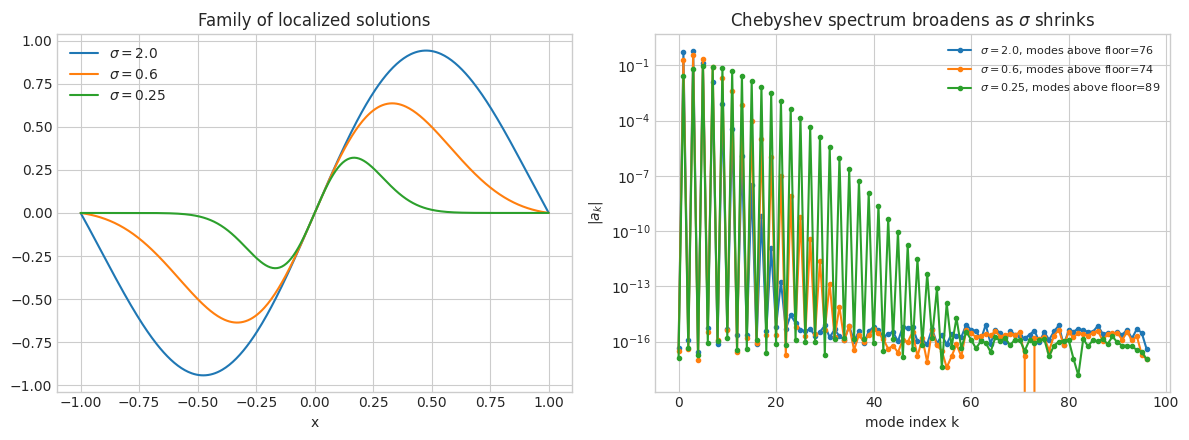

In [9]:
sigmas = [2.0, 0.6, 0.25]
n_spec = 96
x_spec = cheb_nodes(n_spec)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for sigma in sigmas:
    u_sym_s = sp.sin(sp.pi * x_sym) * sp.exp(-(x_sym ** 2) / (sigma ** 2))
    u_np_s = sp.lambdify(x_sym, u_sym_s, "numpy")
    vals = u_np_s(x_spec)
    coeffs = np.abs(np.polynomial.chebyshev.chebfit(x_spec, vals, n_spec))
    floor = np.finfo(float).eps * np.max(coeffs)
    n_above = int(np.sum(coeffs > floor))
    axes[0].plot(np.linspace(-1, 1, 401), u_np_s(np.linspace(-1, 1, 401)), label=rf"$\sigma={sigma}$")
    axes[1].semilogy(np.arange(len(coeffs)), coeffs, "o-", markersize=3, label=rf"$\sigma={sigma}$, modes above floor={n_above}")
axes[0].set_title("Family of localized solutions")
axes[0].set_xlabel("x")
axes[0].legend()
axes[1].set_title(r"Chebyshev spectrum broadens as $\sigma$ shrinks")
axes[1].set_xlabel("mode index k")
axes[1].set_ylabel(r"$|a_k|$")
axes[1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Chebyshev Convergence Shifts With Smoothness

We close the loop by repeating the Chebyshev convergence sweep for the narrowest bump $\sigma = 0.25$. The convergence is still spectral but it kicks in only after roughly $n \approx 30$, mirroring the widening spectrum above. This is the direct numerical analogue of what PINN spectral-bias experiments show: bandwidth sets difficulty.

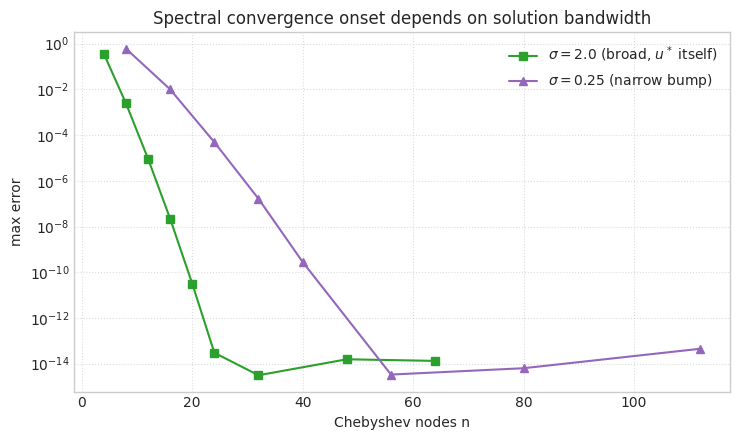

In [10]:
sigma = 0.25
u_sym_s = sp.sin(sp.pi * x_sym) * sp.exp(-(x_sym ** 2) / (sigma ** 2))
f_sym_s = -sp.diff(u_sym_s, x_sym, 2)
u_exact_s = sp.lambdify(x_sym, u_sym_s, "numpy")
f_exact_s = sp.lambdify(x_sym, sp.simplify(f_sym_s), "numpy")

def solve_poisson_cheb_s(n):
    x, D = cheb_differentiation_matrix(n)
    D2 = D @ D
    interior = np.arange(1, n)
    A = D2[np.ix_(interior, interior)]
    b = -f_exact_s(x[interior])
    u_inner = np.linalg.solve(A, b)
    u = np.zeros(n + 1)
    u[interior] = u_inner
    return x, u

cheb_sizes_s = [8, 16, 24, 32, 40, 56, 80, 112]
cheb_errs_s = []
for n in cheb_sizes_s:
    x_n, u_n = solve_poisson_cheb_s(n)
    cheb_errs_s.append(np.max(np.abs(u_n - u_exact_s(x_n))))

plt.figure(figsize=(7.5, 4.5))
plt.semilogy(cheb_sizes, cheb_errs, "s-", color="tab:green", label=r"$\sigma=2.0$ (broad, $u^*$ itself)")
plt.semilogy(cheb_sizes_s, cheb_errs_s, "^-", color="tab:purple", label=r"$\sigma=0.25$ (narrow bump)")
plt.xlabel("Chebyshev nodes n")
plt.ylabel("max error")
plt.title("Spectral convergence onset depends on solution bandwidth")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

## Connection to the Rest of the Repo

The patterns above are reused in several downstream notebooks:

- `03_neural_network_function_approximation.ipynb` asks the mirror question: when a neural network approximates the same $u^*$, which spectral modes does it pick up first?
- `01_Core_Path/09_fourier_neural_operator.ipynb` makes the global mode view differentiable, trading a Chebyshev solver for a learnable spectral operator.
- `06_scalable_methods` will run into the same bandwidth-vs-effort trade-off when problems develop sharp boundary layers.

Treating PINN difficulty as a *spectral* problem rather than a *network-architecture* problem is one of the most reliable mental models in this repo.

## Key Takeaways

- For a smooth 1D Poisson target, finite differences give $O(h^2)$ and Chebyshev collocation gives exponential convergence that bottoms out at machine precision around $n \sim 20$.
- The Chebyshev amplitude spectrum is the single object that explains that gift: an analytic solution concentrates almost all of its energy in a handful of low modes.
- Shrinking solution support broadens the spectrum and pushes the spectral-convergence onset to larger $n$, a direct numerical analogue of why PINN training slows down on localized features.
- Operators built with `torch.autograd` (notebook 01) and operators built with a spectral differentiation matrix (this notebook) target the same derivatives; the choice is about convergence rate, not about correctness.

## References

- Trefethen, Lloyd N. *Spectral Methods in MATLAB*. SIAM, 2000.
- Boyd, John P. *Chebyshev and Fourier Spectral Methods*. Dover, 2001.
- Canuto, Claudio; Hussaini, M. Yousuff; Quarteroni, Alfio; Zang, Thomas A. *Spectral Methods: Fundamentals in Single Domains*. Springer, 2006.
- Rahimi, Ali; Recht, Benjamin. *Random Features for Large-Scale Kernel Machines*. NeurIPS, 2007. (for spectral-bias link) 